In [26]:
import pandas as pd 
import numpy as np


In [27]:
df1 = pd.read_excel("D:/retail_project_1/data/raw/online_retail_II.xlsx",sheet_name="Year 2009-2010")
df2 = pd.read_excel("D:/retail_project_1/data/raw/online_retail_II.xlsx",sheet_name="Year 2010-2011")


df = pd.concat([df1,df2], ignore_index=True)

In [28]:
df.shape

(1067371, 8)

In [29]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [30]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [31]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


Data Cleaning

In [61]:
data_clean = df.copy()


In [62]:
data_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [63]:
print("Shape of original DataFrame:", df.shape)
data_clean = data_clean.dropna(subset=["Customer ID"])
print("Shape of cleaned DataFrame:", data_clean.shape)

Shape of original DataFrame: (1067371, 8)
Shape of cleaned DataFrame: (824364, 8)


In [64]:
data_clean["Invoice"] = data_clean["Invoice"].astype(str)
data_clean["StockCode"] = data_clean["StockCode"].astype(str)
data_clean["Description"] = data_clean["Description"].astype(str)

In [65]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  str           
 1   StockCode    824364 non-null  str           
 2   Description  824364 non-null  str           
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[us]
 5   Price        824364 non-null  float64       
 6   Customer ID  824364 non-null  float64       
 7   Country      824364 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 96.9 MB


In [66]:
data_clean["InvoiceDate"] = pd.to_datetime(data_clean["InvoiceDate"])
print("from", data_clean["InvoiceDate"].min())
print("to", data_clean["InvoiceDate"].max())

from 2009-12-01 07:45:00
to 2011-12-09 12:50:00


In [67]:
cancellations = data_clean[data_clean['Invoice'].str.startswith('C')]
print("\nCancellations:", len(cancellations))


Cancellations: 18744


In [68]:
cancellations.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [69]:
data_clean = data_clean[~data_clean['Invoice'].str.startswith('C')]
print("\nCleaned DataFrame shape:", data_clean.shape)


Cleaned DataFrame shape: (805620, 8)


In [70]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  str           
 1   StockCode    805620 non-null  str           
 2   Description  805620 non-null  str           
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 95.0 MB


In [71]:
duplicates = data_clean.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 26125


In [72]:
data_clean[data_clean.duplicated()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [73]:
data_clean = data_clean.drop_duplicates()

In [74]:
duplicates = data_clean.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [75]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  str           
 1   StockCode    779495 non-null  str           
 2   Description  779495 non-null  str           
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[us]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  float64       
 7   Country      779495 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 91.9 MB


In [80]:
data_clean[data_clean["Price"] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.0,15602.0,United Kingdom
1005014,577168,M,Manual,1,2011-11-18 10:42:00,0.0,12603.0,Germany
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.0,12444.0,Norway
1011446,577696,M,Manual,1,2011-11-21 11:57:00,0.0,16406.0,United Kingdom


In [79]:
(data_clean["Price"] <= 0).sum()

np.int64(70)

In [81]:
data_clean = data_clean[data_clean["Price"] > 0]

In [82]:
(data_clean["Price"] <= 0).sum()

np.int64(0)

In [10]:
print("Unique Products:", df["StockCode"].nunique())
print("Unique Customer IDs:", df["Customer ID"].nunique())
print("Unique Countries:", df["Country"].nunique())

Unique Products: 5305
Unique Customer IDs: 5942
Unique Countries: 43


EDA

How did the company revenue change over time?

In [11]:
df_clean["total_price"] = (df_clean["Quantity"] * df_clean["Price"])
df_clean["total_price"].head()
print(df_clean["total_price"].sum())

20813918.428


In [12]:
df["total_price"] = (df["Quantity"] * df["Price"])
df["total_price"].head()
print(df["total_price"].sum())

19287250.568


Cancellations reduced total recorded revenue by £1.5 million — representing 7.3% of gross revenue

In [13]:
monthly_revenue = (
    df_clean.groupby(df_clean["InvoiceDate"].dt.to_period("M"))["total_price"].sum().reset_index()
)

In [14]:
import matplotlib.pyplot as plt

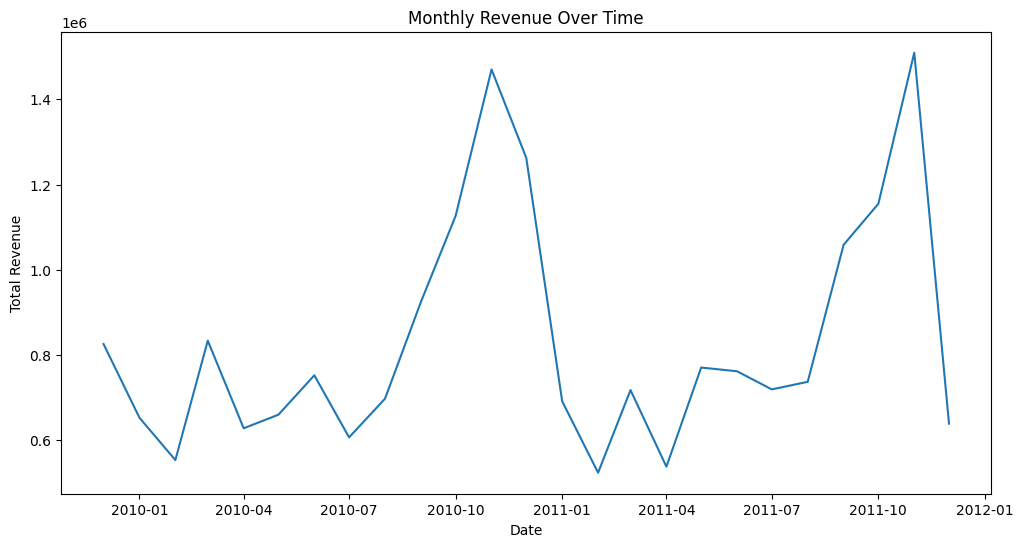

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["InvoiceDate"].dt.to_timestamp(), monthly_revenue["total_price"], label="With Cancellations")  
plt.title("Monthly Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue_1["InvoiceDate"].dt.to_timestamp(), monthly_revenue_1["total_price"])  
plt.title("Monthly Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

NameError: name 'monthly_revenue_1' is not defined

<Figure size 1200x600 with 0 Axes>

Insights:
1. Revenue shows strong seasonal spikes during late-year holiday periods.
2. 2011 revenue generally exceeds 2010 revenue, indicating business growth.
3. The sharp decline in December 2011 is likely due to incomplete monthly data because the dataset ends before the month completed.

Where are customers coming from?

In [ ]:
df_top_countries = (df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(10))

In [ ]:
df_top_countries

Country
United Kingdom    49108
Germany            1095
EIRE                806
France              746
Netherlands         250
Spain               188
Belgium             183
Sweden              129
Portugal            124
Switzerland         123
Name: Invoice, dtype: int64

Text(0, 0.5, 'Number of Transactions')

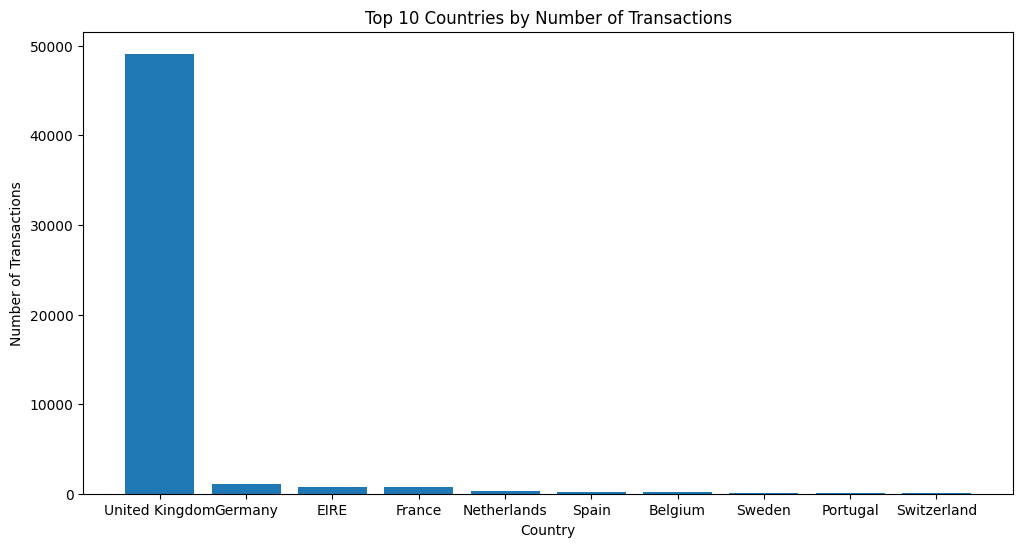

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(df_top_countries.index, df_top_countries.values)
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

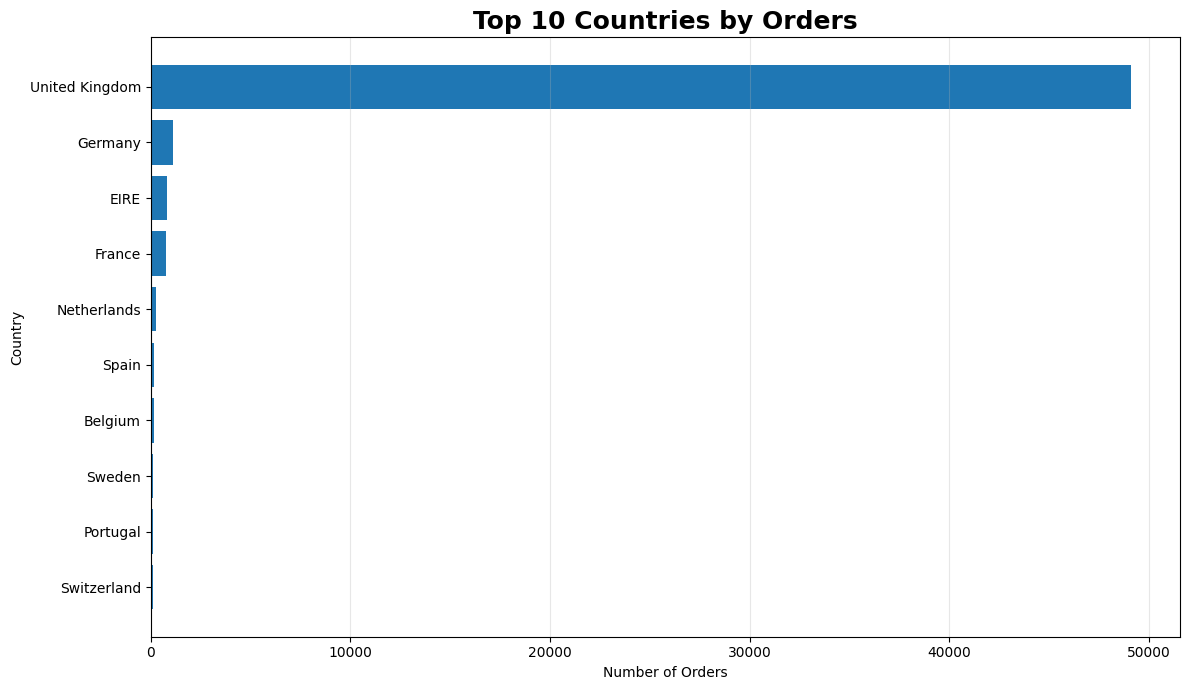

In [ ]:
plt.figure(figsize=(12,7))

plt.barh(
    df_top_countries.index,
    df_top_countries.values
)

plt.title(
    "Top 10 Countries by Orders",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Orders")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

Insight:
The United Kingdom overwhelmingly dominates transaction volume, contributing the vast majority of orders. This validates restricting the churn analysis to UK customers for a cleaner and more reliable behavioral model. After excluding the UK, Germany, EIRE, and France emerge as the strongest international markets.

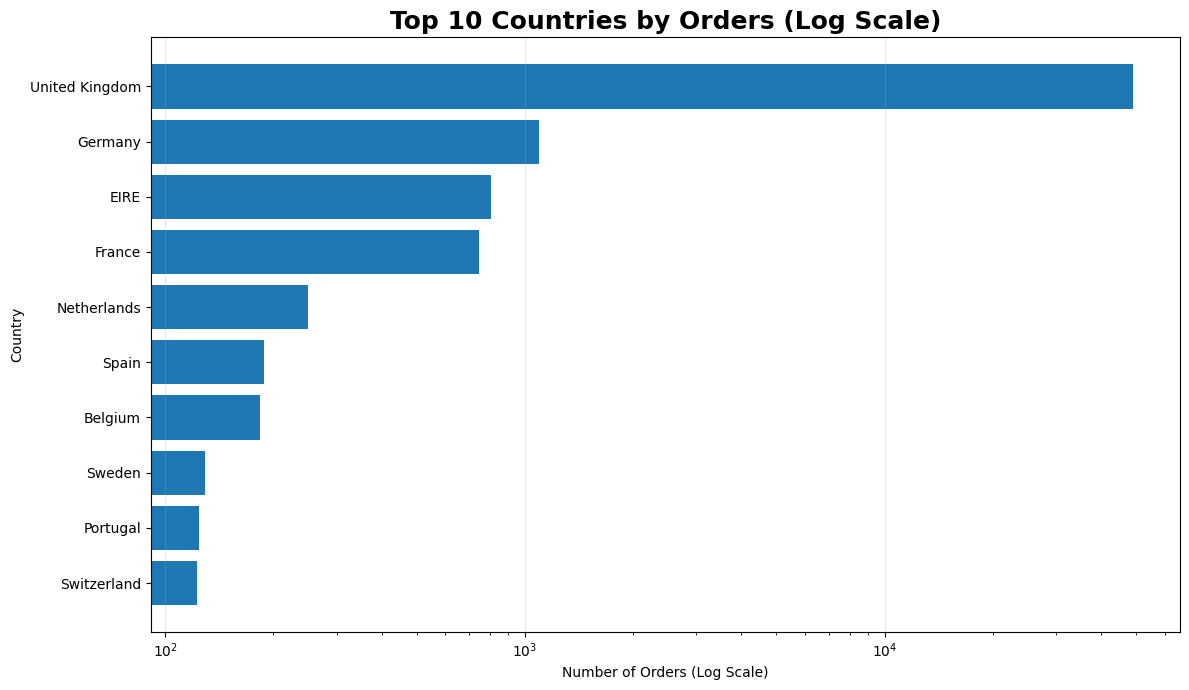

In [ ]:
plt.figure(figsize=(12,7))

plt.barh(
    df_top_countries.index,
    df_top_countries.values
)

plt.xscale("log")

plt.title(
    "Top 10 Countries by Orders (Log Scale)",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Orders (Log Scale)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

Are cancellations increasing or decreasing?

In [ ]:
cancellations.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [ ]:
cancellations_overtime =cancellations.groupby(cancellations["InvoiceDate"].dt.to_period("M"))["Invoice"].nunique().reset_index()
print(cancellations_overtime.head())

  InvoiceDate  Invoice
0     2009-12      401
1     2010-01      300
2     2010-02      240
3     2010-03      407
4     2010-04      304


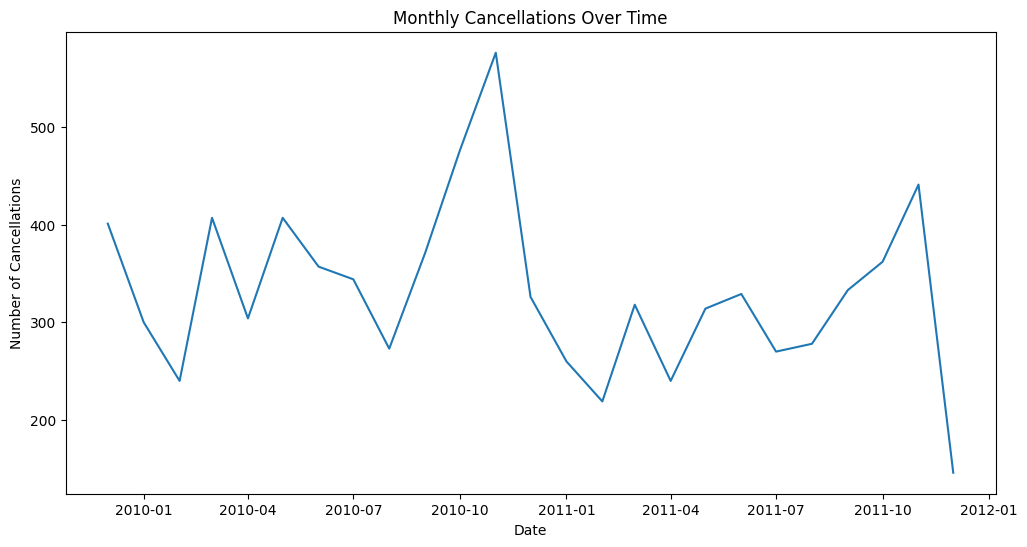

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(cancellations_overtime["InvoiceDate"].dt.to_timestamp(), cancellations_overtime["Invoice"])
plt.title("Monthly Cancellations Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Cancellations")
plt.show()

Cancellations averaged 330 per month with notable spikes in October 2010 (570) and November 2011 (440), both coinciding with peak Christmas trading periods. This suggests seasonal fulfillment pressure drives higher return rates — a recurring operational risk every Q4.

Which products make the most revenue?

In [ ]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
df_top_products =df_clean.groupby("Description")["total_price"].sum().sort_values(ascending=False).head(10)

C:\Users\devan\AppData\Local\Temp\ipykernel_26472\2393670423.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20c")


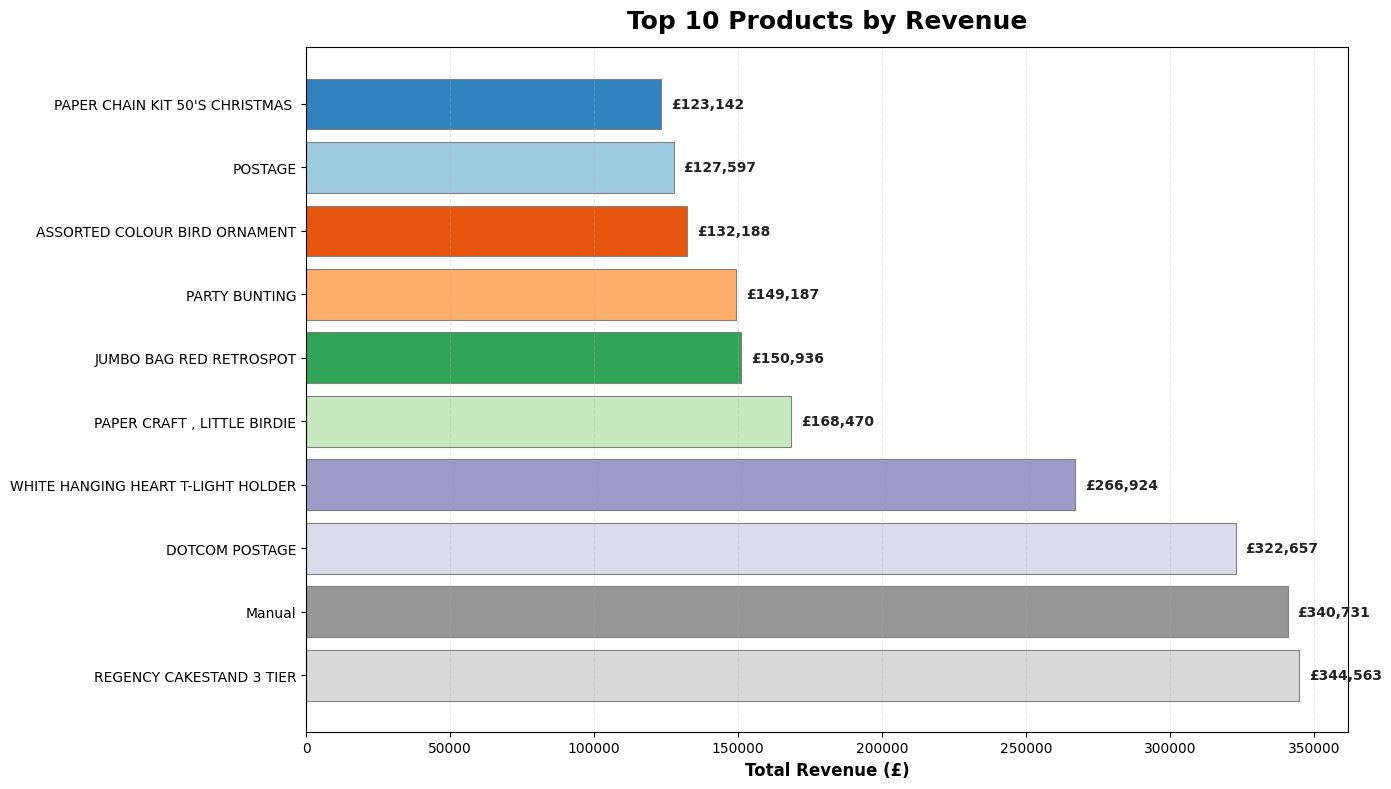

In [ ]:
# colorful horizontal bar chart for top 10 products by revenue
top = df_top_products.sort_values(ascending=False)  # descending: largest first
top = df_top_products.sort_values()  # ascending for nice horizontal layout
cmap = plt.cm.get_cmap("tab20c")
colors = cmap(np.linspace(0, 1, len(top)))

plt.figure(figsize=(14, 8))
bars = plt.barh(top.index, top.values, color=colors, edgecolor='gray', linewidth=0.8)

# value labels
maxv = top.values.max()
for bar, val in zip(bars, top.values):
    plt.text(val + maxv * 0.01, bar.get_y() + bar.get_height() / 2,
             f'£{val:,.0f}', va='center', ha='left', fontsize=10, fontweight='bold', color='#222222')

plt.title("Top 10 Products by Revenue", fontsize=18, fontweight='bold', pad=14)
plt.xlabel("Total Revenue (£)", fontsize=12, fontweight='semibold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_distribution = df_clean.groupby("Invoice")["total_price"].sum().reset_index()

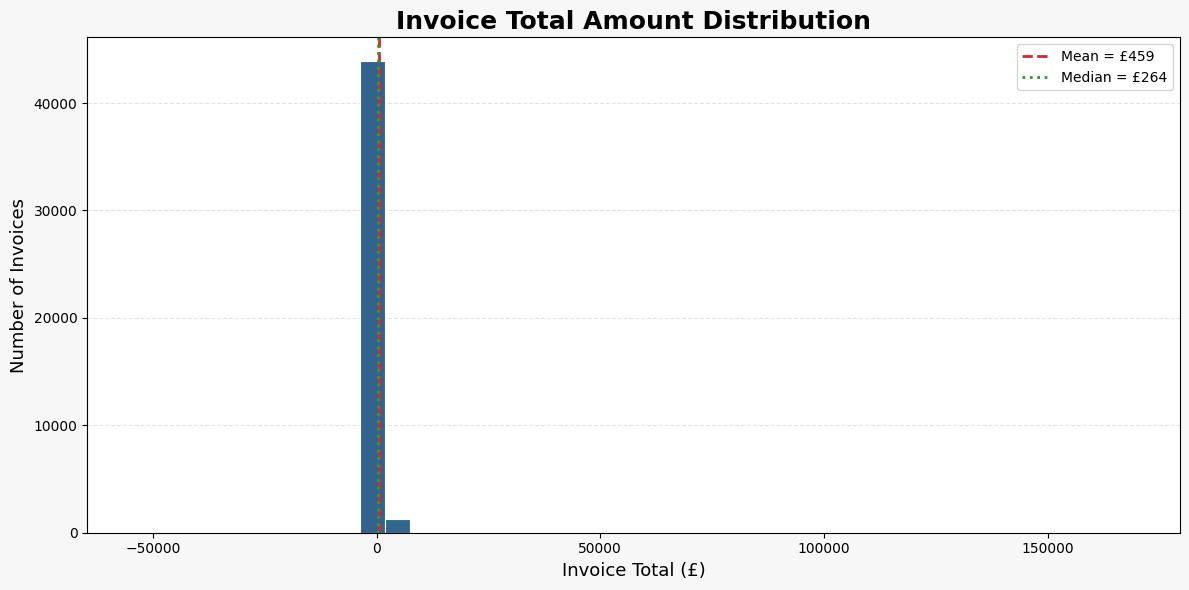

In [ ]:
invoice_totals = df_clean.groupby("Invoice")["total_price"].sum()

fig, ax = plt.subplots(figsize=(12, 6), facecolor="#f7f7f7")
counts, bins, patches = ax.hist(invoice_totals, bins=40)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("white")
    patch.set_linewidth(0.8)

mean_val = invoice_totals.mean()
median_val = invoice_totals.median()

ax.axvline(mean_val, color="#d62728", linestyle="--", linewidth=2, label=f"Mean = £{mean_val:,.0f}")
ax.axvline(median_val, color="#2ca02c", linestyle=":", linewidth=2, label=f"Median = £{median_val:,.0f}")

ax.set_title("Invoice Total Amount Distribution", fontsize=18, fontweight="bold")
ax.set_xlabel("Invoice Total (£)", fontsize=13)
ax.set_ylabel("Number of Invoices", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

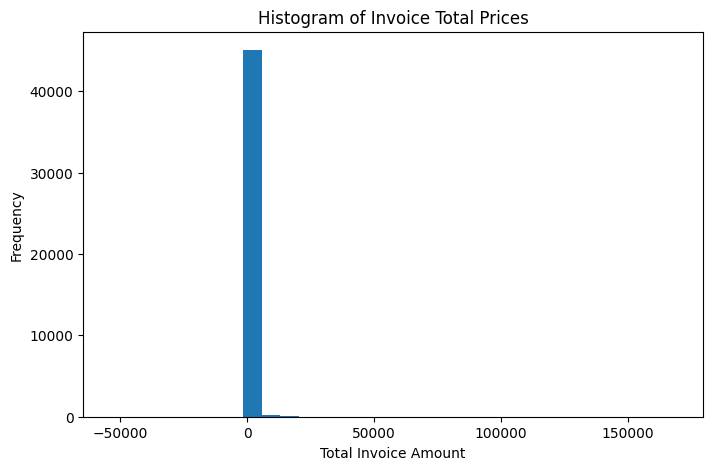

In [ ]:
invoice_totals = df_clean.groupby("Invoice")["total_price"].sum()

# Step 2: Plot histogram
plt.figure(figsize=(8,5))
plt.hist(invoice_totals, bins=30)

plt.xlabel("Total Invoice Amount")
plt.ylabel("Frequency")
plt.title("Histogram of Invoice Total Prices")

plt.show()

In [ ]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [ ]:
df_clean["Day"] = df_clean["InvoiceDate"].dt.day_name()
print(df_clean["Day"].head())
order_by_day = df_clean.groupby("Day")["Invoice"].nunique()

reorder = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

order_by_day = order_by_day.reindex(reorder)



0    Tuesday
1    Tuesday
2    Tuesday
3    Tuesday
4    Tuesday
Name: Day, dtype: str


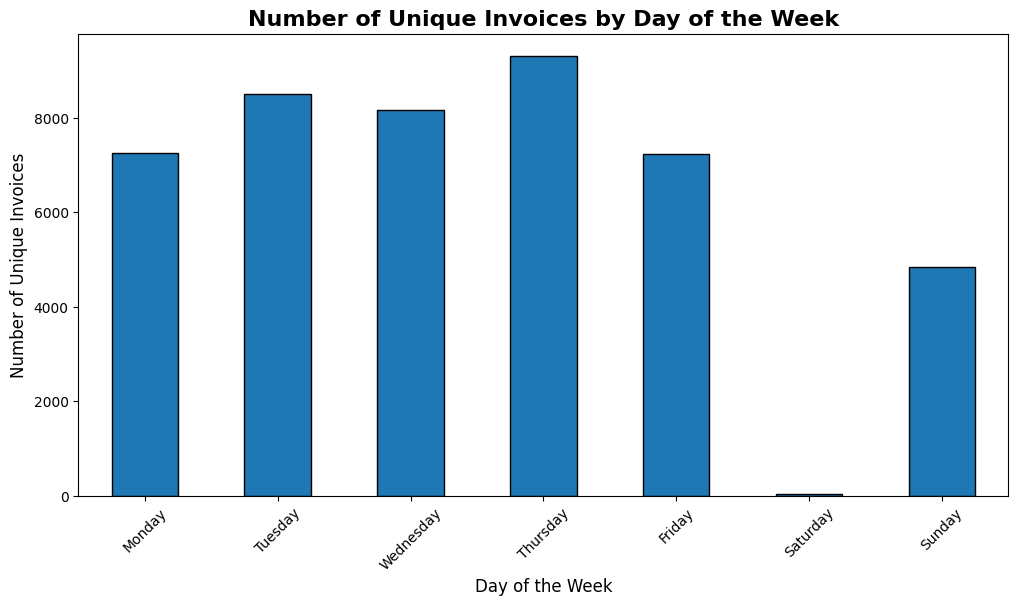

In [ ]:
plt.figure(figsize=(12, 6))
order_by_day.plot(kind="bar", color="#1f77b4", edgecolor="black")
plt.title("Number of Unique Invoices by Day of the Week", fontsize=16, fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Unique Invoices", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_clean["Hour"]= df_clean["InvoiceDate"].dt.hour
order_by_hour = df_clean.groupby("Hour")["Invoice"].nunique()


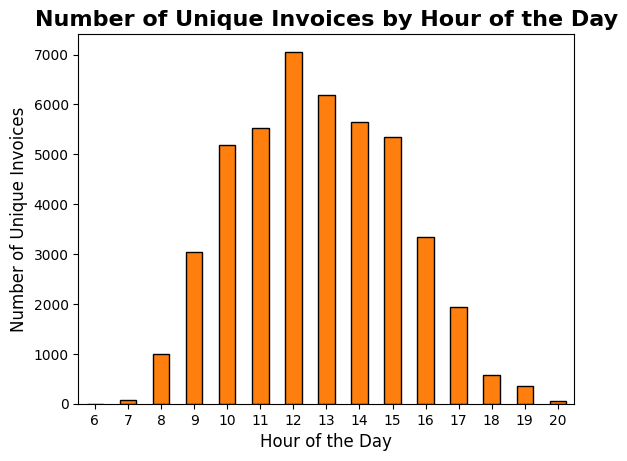

In [ ]:
order_by_hour.plot(kind="bar", color="#ff7f0e", edgecolor="black")
plt.title("Number of Unique Invoices by Hour of the Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Number of Unique Invoices", fontsize=12)
plt.xticks(rotation=0)
plt.show()

In [ ]:
df_clean["Region"]= df_clean["Country"].apply(lambda x: "United Kingdom" if x == "United Kingdom" else "International")
region_counts = df_clean.groupby("Region")["total_price"].sum()

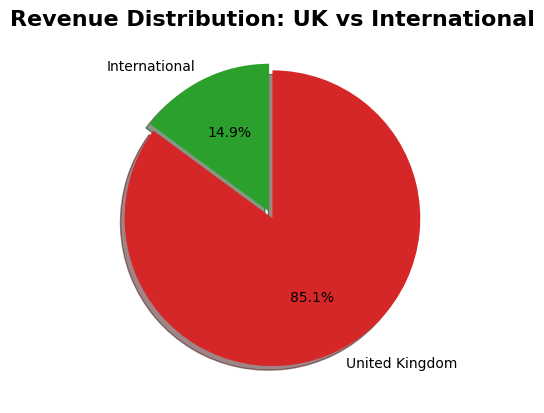

In [ ]:
region_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["#2ca02c", "#d62728"], explode=[0.05, 0], shadow=True)
plt.title("Revenue Distribution: UK vs International", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Invoice        1067371 non-null  str           
 1   StockCode      1067371 non-null  object        
 2   Description    1062989 non-null  object        
 3   Quantity       1067371 non-null  int64         
 4   InvoiceDate    1067371 non-null  datetime64[us]
 5   Price          1067371 non-null  float64       
 6   Customer ID    824364 non-null   float64       
 7   Country        1067371 non-null  str           
 8   total_price    1067371 non-null  float64       
 9   total_price_1  1067371 non-null  float64       
 10  Hour           1067371 non-null  int32         
 11  Day            1067371 non-null  str           
 12  Region         1067371 non-null  str           
dtypes: datetime64[us](1), float64(4), int32(1), int64(1), object(2), str(4)
memory usage: 143.0+ MB


In [ ]:
data_clean = df.dropna(subset=['Customer ID'])

In [ ]:
df_clean.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
total_price    0
Hour           0
Day            0
Region         0
dtype: int64